<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Logistic_Regression_Part2_Perceptron_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

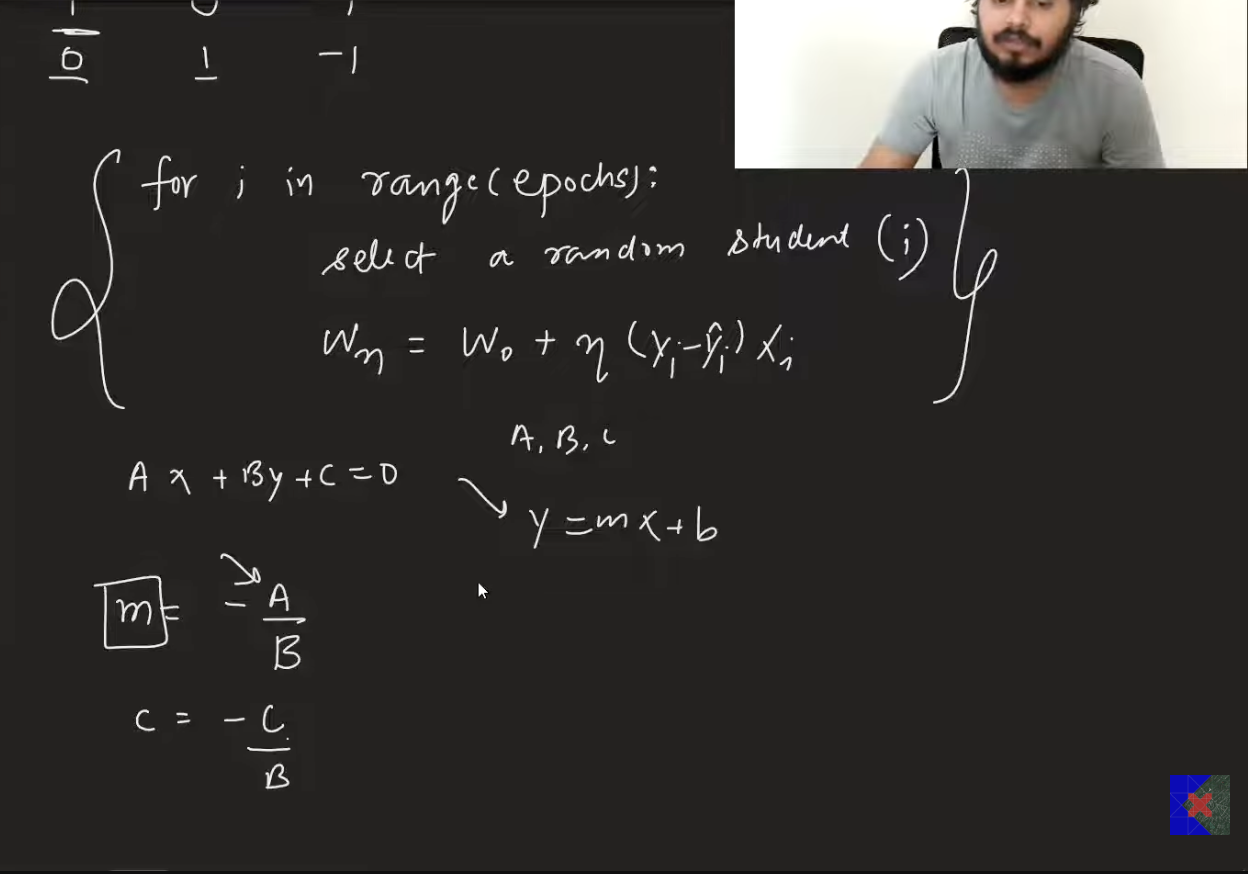

In [174]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=4, hypercube=False, class_sep=10)

In [175]:
import matplotlib.pyplot as plt

In [176]:
X

array([[  0.51681073,   3.97020423],
       [  0.46245999,   5.36600434],
       [ -0.5292739 ,  -9.15549822],
       [  1.00050563,   5.9737649 ],
       [  0.96826119,   4.85484289],
       [ -1.61013768,  -8.86359847],
       [ -0.42330897,  -8.61265076],
       [  1.07428154,   3.78722465],
       [ -0.32217298,   4.64409726],
       [ -1.19528179,  -8.0807207 ],
       [ -0.11916449,   6.30584088],
       [ -0.13049162,   6.62964533],
       [  0.92968507,  -8.81775776],
       [ -0.60671494,   5.46949553],
       [  0.07445564,   5.52659631],
       [ -0.33476493,   6.1633594 ],
       [ -0.46878782,  -8.13643039],
       [ -1.24660636,   4.47089793],
       [  1.20836238,   6.24169582],
       [ -0.48781516,   4.7069487 ],
       [ -0.51108662,  -8.45001305],
       [ -0.4532145 ,   5.52406267],
       [ -0.32355154,   5.46557936],
       [ -0.86575871,  -9.38022459],
       [ -0.72200832,  -9.41570824],
       [ -1.03479122,   6.82322427],
       [ -0.18478572,   4.91668687],
 

In [177]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:,0], X[:,1], c= y, cmap='winter', s=100)

<IPython.core.display.Javascript object>

In [178]:
def perceptron(X, y):
  X = np.insert(X, 0, 1, axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j], weights))
    weights = weights + lr*(y[j]-y_hat)*X[j]

  return weights[0], weights[1:]

In [179]:
def step(z):
  return 1 if z > 0 else 0

In [180]:
intercept_,coef_ = perceptron(X,y)

In [181]:
print(coef_)
print(intercept_)

[1. 1.]
1.0


In [182]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [183]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

In [184]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input, color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1], c=y, cmap= 'winter',s=100)
# plt.ylim(-3,2)

<IPython.core.display.Javascript object>

# Animation

In [185]:
def perceptron(X,y):

    m = []
    b = []

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))

    return m,b
m,b = perceptron(X,y)
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)

def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)

<IPython.core.display.Javascript object>

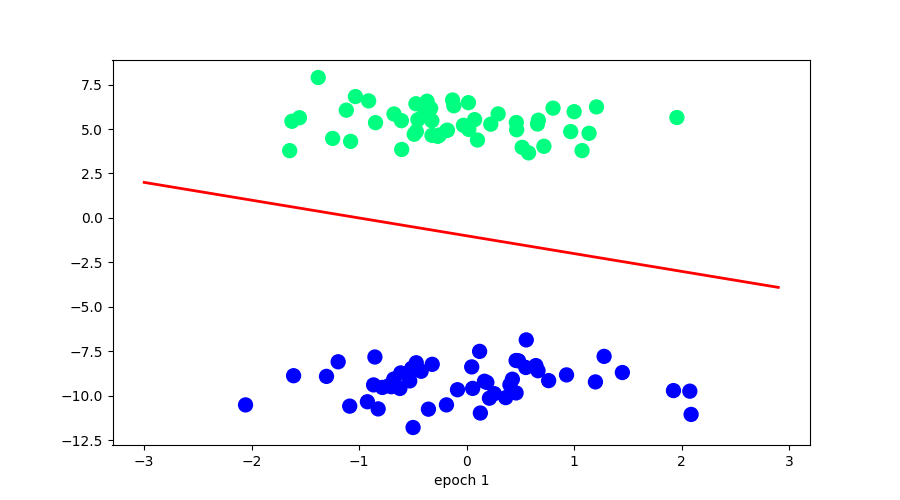

In [186]:
anim.save("perceptron.gif", writer="pillow")

from IPython.display import Image
Image("perceptron.gif")

In [187]:
from sklearn.linear_model import LogisticRegression

lor = LogisticRegression()
lor.fit(X, y)


LogisticRegression()

In [188]:

m = -(lor.coef_[0][0] / lor.coef_[0][1])
b = -(lor.intercept_[0] / lor.coef_[0][1])

x_input1 = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_input1 = m*x_input1 + b


In [189]:
print("Perceptron:")
print(m, b)

print("Logistic:")
print(lor.coef_)
print(lor.intercept_)

print("X range:")
print(X[:,0].min(), X[:,0].max())
print(X[:,1].min(), X[:,1].max())

Perceptron:
0.010371814741306605 -1.9186407547844906
Logistic:
[[-0.00983618  0.94835663]]
[1.81955568]
X range:
-2.0569478063413356 2.088805790207947
-11.773522564761194 7.894439756908319


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

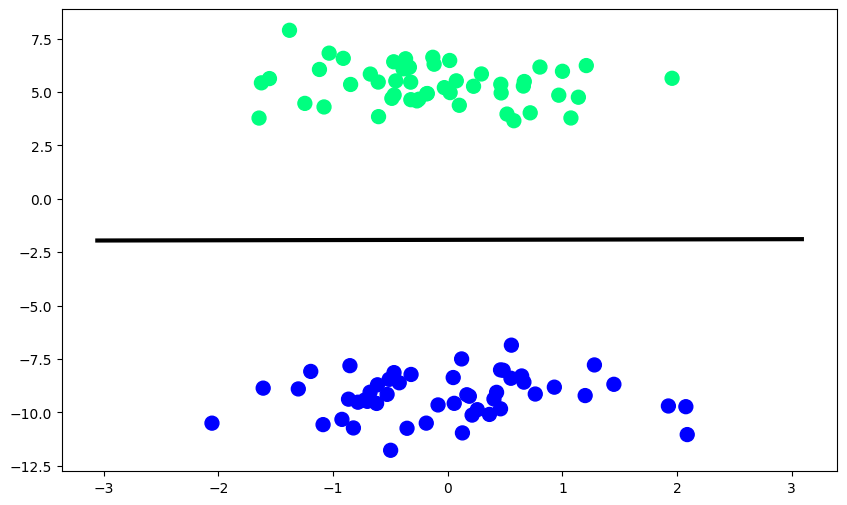

AttributeError: 'NoneType' object has no attribute 'remove_callback'

In [190]:
%matplotlib inline
plt.figure(figsize=(10,6))
plt.plot(x_input1, y_input1, color='black', linewidth=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)
